In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [2]:
personas = pd.read_csv("../outputs/customer_personas.csv")
rfm = pd.read_csv("../outputs/rfm_raw.csv")
nlp = pd.read_csv("../outputs/nlp_features.csv")
agent = pd.read_csv("../outputs/agent_actions.csv")
apriori = pd.read_csv("../outputs/persona_apriori_rules.csv")

In [3]:
merged = (
    personas
    .merge(rfm, on="customer_unique_id", how="left")
    .merge(nlp, on="customer_unique_id", how="left")
)

merged.head()

,customer_unique_id,recency_x,frequency_x,monetary_x,nlp_1_x,nlp_2_x,cluster,persona,recency_y,frequency_y,monetary_y,nlp_1_y,nlp_2_y
0,0000366f3b9a7992bf8c76cfdf3221e2,0.157967,0.0,0.009603,7.955969,0.534592,1,Silent Loyal Customers,116,1,129.90,7.955969,0.534592
1,0000f6ccb0745a6a4b88665a16c9f078,0.446429,0.0,0.001871,13.129206,11.164166,0,High-Value Enthusiasts,326,1,25.99,13.129206,11.164166
2,00053a61a98854899e70ed204dd4bafe,0.255495,0.0,0.028361,4.529376,4.633020,0,High-Value Enthusiasts,187,1,382.00,4.529376,4.633020
3,0005ef4cd20d2893f0d9fbd94d3c0d97,0.239011,0.0,0.007742,5.494314,1.528532,1,Silent Loyal Customers,175,1,104.90,5.494314,1.528532
4,0006fdc98a402fceb4eb0ee528f6a8d4,0.564560,0.0,0.000971,5.508366,-0.480954,1,Silent Loyal Customers,412,1,13.90,5.508366,-0.480954


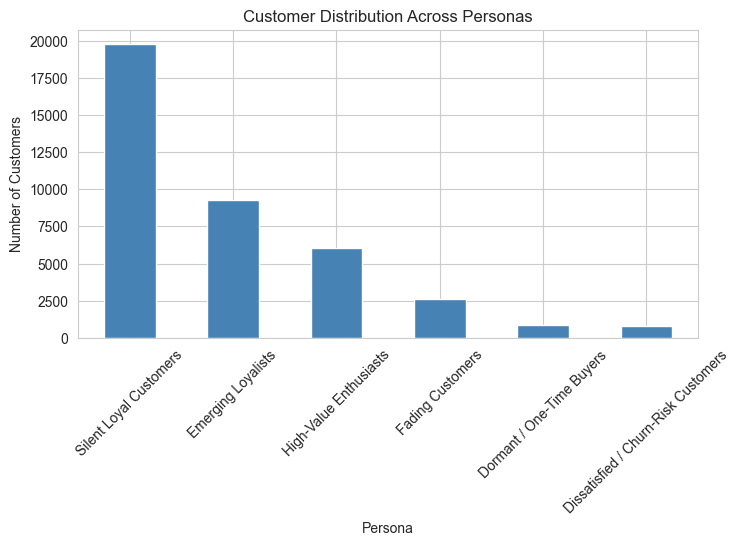

In [4]:
persona_counts = personas["persona"].value_counts()

persona_counts.plot(
    kind="bar",
    color="steelblue",
    title="Customer Distribution Across Personas"
)

plt.ylabel("Number of Customers")
plt.xlabel("Persona")
plt.xticks(rotation=45)
plt.show()

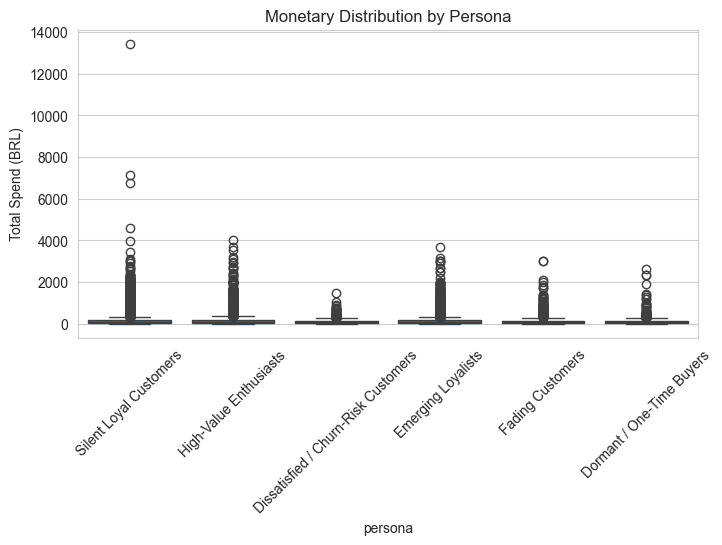

In [6]:
sns.boxplot(
    data=merged,
    x="persona",
    y="monetary_y"
)

plt.xticks(rotation=45)
plt.title("Monetary Distribution by Persona")
plt.ylabel("Total Spend (BRL)")
plt.show()

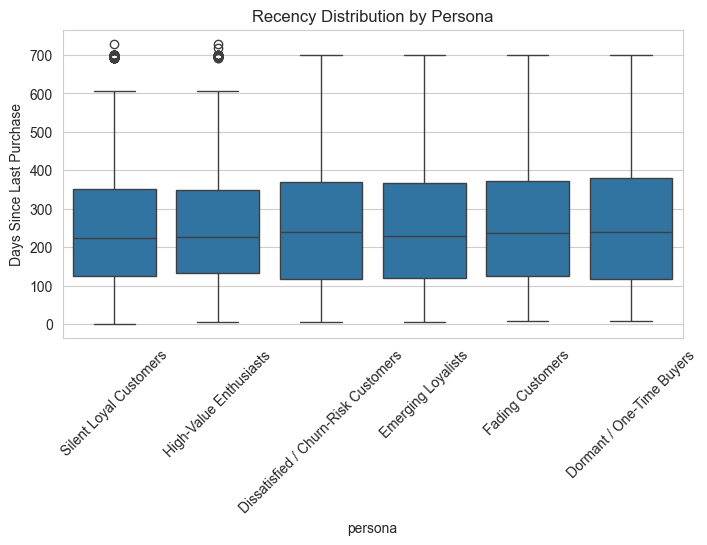

In [7]:
sns.boxplot(
    data=merged,
    x="persona",
    y="recency_y"
)

plt.xticks(rotation=45)
plt.title("Recency Distribution by Persona")
plt.ylabel("Days Since Last Purchase")
plt.show()

In [10]:
# ---- Clean duplicated NLP features ----

# Keep the final NLP representation
merged = merged.rename(columns={
    "nlp_1_y": "nlp_1",
    "nlp_2_y": "nlp_2"
})

# Drop redundant columns
merged = merged.drop(columns=[
    "nlp_1_x", "nlp_2_x"
])

In [11]:
merged = merged.rename(columns={
    "recency_y": "recency",
    "frequency_y": "frequency",
    "monetary_y": "monetary"
})

merged = merged.drop(columns=[
    "recency_x", "frequency_x", "monetary_x"
])

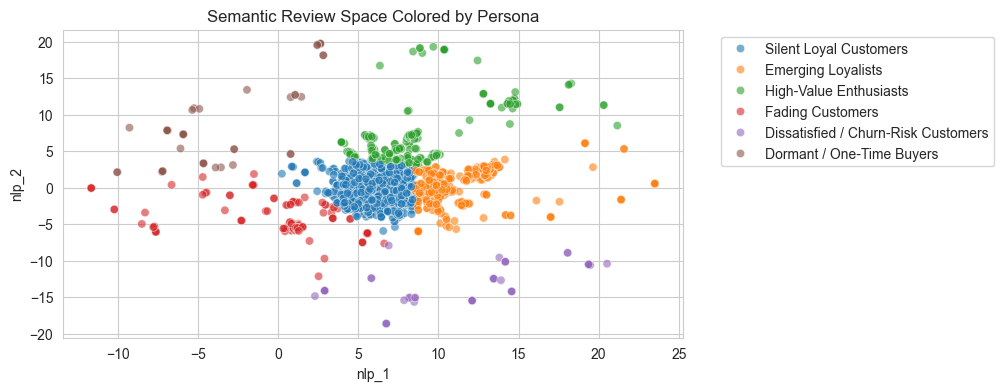

In [12]:
sns.scatterplot(
    data=merged.sample(2000, random_state=42),
    x="nlp_1",
    y="nlp_2",
    hue="persona",
    alpha=0.6,
    palette="tab10"
)

plt.title("Semantic Review Space Colored by Persona")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

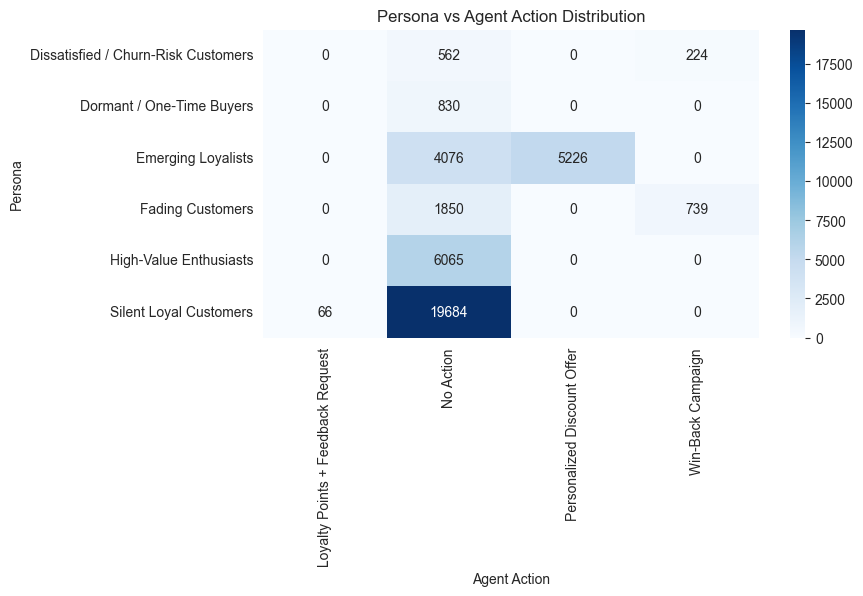

In [13]:
action_matrix = pd.crosstab(
    agent["persona"],
    agent["agent_action"]
)

sns.heatmap(
    action_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Persona vs Agent Action Distribution")
plt.xlabel("Agent Action")
plt.ylabel("Persona")
plt.show()

In [14]:
top_rules = (
    apriori
    .sort_values("lift", ascending=False)
    .groupby("persona")
    .head(3)
)

top_rules[["persona", "antecedents", "consequents", "lift"]]

,persona,antecedents,consequents,lift
4,Fading Customers,frozenset({'moveis_sala'}),frozenset({'moveis_escritorio'}),30.571429
10,Emerging Loyalists,frozenset({'cool_stuff'}),frozenset({'brinquedos'}),15.407407
5,Fading Customers,frozenset({'bebes'}),frozenset({'brinquedos'}),10.190476
6,Fading Customers,frozenset({'artes'}),frozenset({'moveis_decoracao'}),6.687500
1,High-Value Enthusiasts,frozenset({'artes'}),frozenset({'moveis_decoracao'}),4.950725
11,Emerging Loyalists,frozenset({'casa_conforto'}),frozenset({'cama_mesa_banho'}),4.571429
12,Emerging Loyalists,frozenset({'casa_construcao'}),frozenset({'ferramentas_jardim'}),4.170426
2,High-Value Enthusiasts,frozenset({'casa_conforto'}),frozenset({'cama_mesa_banho'}),3.713043
3,High-Value Enthusiasts,frozenset({'construcao_ferramentas_iluminacao'}),frozenset({'moveis_decoracao'}),3.713043
0,Silent Loyal Customers,frozenset({'casa_conforto'}),frozenset({'cama_mesa_banho'}),3.144027


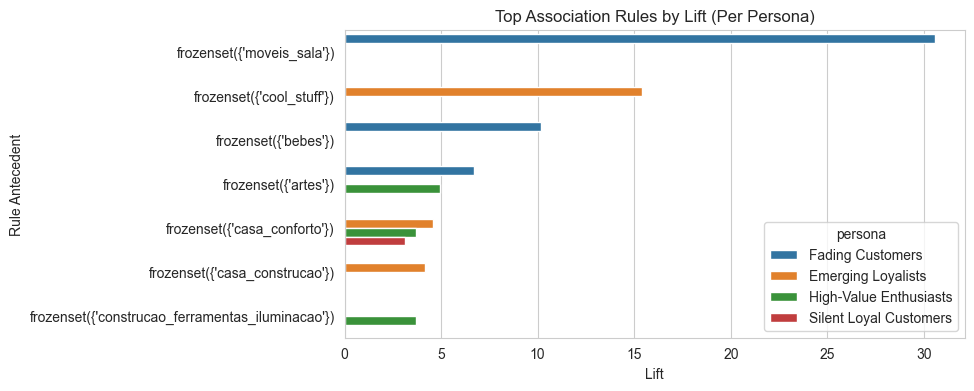

In [15]:
sns.barplot(
    data=top_rules,
    x="lift",
    y=top_rules["antecedents"].astype(str),
    hue="persona"
)

plt.title("Top Association Rules by Lift (Per Persona)")
plt.xlabel("Lift")
plt.ylabel("Rule Antecedent")
plt.show()